<a href="https://colab.research.google.com/github/DKB-004/Markowitz_portfolio./blob/main/markowitz_portfolio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [ ]:
stocks = ['RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS', 'INFY.NS', 'WIPRO.NS']


data = yf.download(stocks, start='2024-01-01', end='2026-01-01',progress=False)['Close']

print("Shape:", data.shape)
print("\nFirst 5 rows:")
print(data.head())
print("\nMissing values:")
print(data.isnull().sum())

/tmp/ipykernel_9219/4135401459.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stocks, start='2024-01-01', end='2026-01-01',


Shape: (495, 5)

First 5 rows:
Ticker      HDFCBANK.NS      INFY.NS  RELIANCE.NS       TCS.NS    WIPRO.NS
Date                                                                      
2024-01-01   826.441040  1460.572388  1285.609619  3549.363037  223.164429
2024-01-02   826.927734  1444.614258  1296.255859  3523.378906  219.446182
2024-01-03   814.176636  1402.812500  1282.160156  3438.209961  213.225754
2024-01-04   822.912598  1424.184082  1288.786011  3414.973145  211.588776
2024-01-05   818.702759  1442.872681  1294.270508  3481.190186  213.553146

Missing values:
Ticker
HDFCBANK.NS    0
INFY.NS        0
RELIANCE.NS    0
TCS.NS         0
WIPRO.NS       0
dtype: int64


In [ ]:
# Daily returns
returns = data.pct_change().dropna()

ann_returns = returns.mean() * 252  #252 trading days in a year

ann_cov = returns.cov() * 252

print("Annualised Expected Returns:")
print(ann_returns.round(4))
print("\nAnnualised Covariance Matrix:")
print(ann_cov.round(4))

Annualised Expected Returns:
Ticker
HDFCBANK.NS    0.1114
INFY.NS        0.0800
RELIANCE.NS    0.1247
TCS.NS        -0.0402
WIPRO.NS       0.1069
dtype: float64

Annualised Covariance Matrix:
Ticker       HDFCBANK.NS  INFY.NS  RELIANCE.NS  TCS.NS  WIPRO.NS
Ticker                                                          
HDFCBANK.NS       0.0370   0.0073       0.0144  0.0042    0.0102
INFY.NS           0.0073   0.0576       0.0116  0.0349    0.0405
RELIANCE.NS       0.0144   0.0116       0.0453  0.0129    0.0181
TCS.NS            0.0042   0.0349       0.0129  0.0421    0.0332
WIPRO.NS          0.0102   0.0405       0.0181  0.0332    0.0712


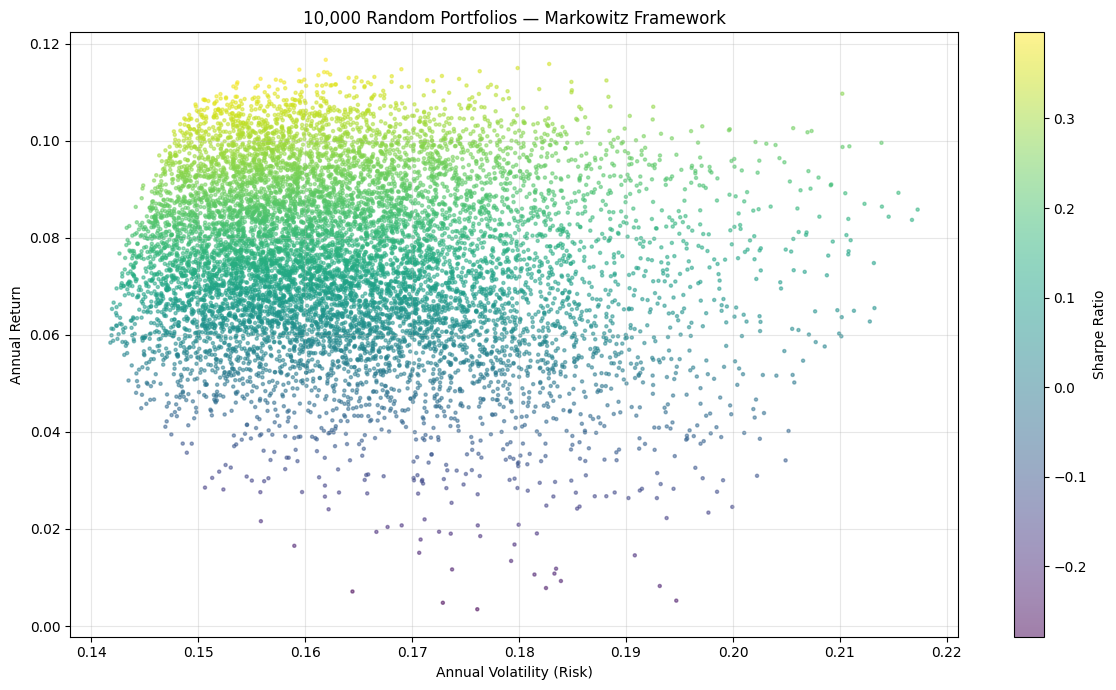

Best Sharpe ratio found : 0.3961
Worst Sharpe ratio found: -0.2785


In [ ]:

n_portfolios = 10_000
n_stocks     = len(stocks)
r_f          = 0.0525

port_returns  = []
port_vols     = []
port_sharpes  = []
port_weights  = []

np.random.seed(42)

for i in range(n_portfolios):
    w = np.random.random(n_stocks)
    w = w / w.sum()

    ret  = np.dot(w, ann_returns)
    vol  = np.sqrt(w @ ann_cov @ w)
    sharpe = (ret - r_f) / vol

    port_returns.append(ret)
    port_vols.append(vol)
    port_sharpes.append(sharpe)
    port_weights.append(w)

port_returns  = np.array(port_returns)
port_vols     = np.array(port_vols)
port_sharpes  = np.array(port_sharpes)
port_weights  = np.array(port_weights)

plt.figure(figsize=(12, 7))
scatter = plt.scatter(port_vols, port_returns,
                      c=port_sharpes, cmap='viridis',
                      alpha=0.5, s=5)
plt.colorbar(scatter, label='Sharpe Ratio')
plt.xlabel('Annual Volatility (Risk)')
plt.ylabel('Annual Return')
plt.title('10,000 Random Portfolios — Markowitz Framework')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best Sharpe ratio found : {port_sharpes.max():.4f}")
print(f"Worst Sharpe ratio found: {port_sharpes.min():.4f}")

                          Equal  Optimised
Annual Return             7.66%     11.66%
Annual Volatility        15.85%     16.19%
Sharpe Ratio             0.1518     0.3961


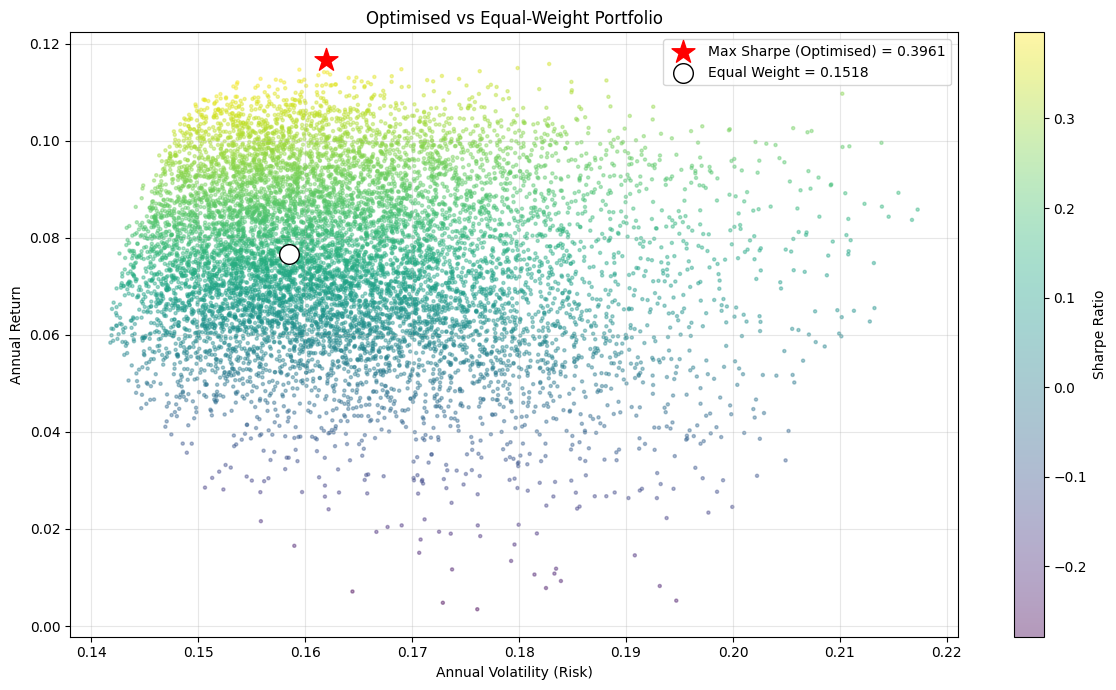

In [ ]:

# Equal weight portfolio
w_equal = np.array([1/n_stocks] * n_stocks)
ret_equal  = np.dot(w_equal, ann_returns)
vol_equal  = np.sqrt(w_equal @ ann_cov @ w_equal)
sharpe_equal = (ret_equal - r_f) / vol_equal

# Optimal portfolio (max Sharpe)
w_opt = port_weights[max_idx]
ret_opt  = np.dot(w_opt, ann_returns)
vol_opt  = np.sqrt(w_opt @ ann_cov @ w_opt)
sharpe_opt = (ret_opt - r_f) / vol_opt


print(f"{'':20s} {'Equal':>10s} {'Optimised':>10s}")

print(f"{'Annual Return':20s} {ret_equal*100:>9.2f}% {ret_opt*100:>9.2f}%")
print(f"{'Annual Volatility':20s} {vol_equal*100:>9.2f}% {vol_opt*100:>9.2f}%")
print(f"{'Sharpe Ratio':20s} {sharpe_equal:>10.4f} {sharpe_opt:>10.4f}")


# Plot comparison on the frontier
plt.figure(figsize=(12, 7))
scatter = plt.scatter(port_vols, port_returns,
                      c=port_sharpes, cmap='viridis',
                      alpha=0.4, s=5)
plt.colorbar(scatter, label='Sharpe Ratio')

plt.scatter(vol_opt, ret_opt, color='red', s=300,
            marker='*', zorder=5,
            label=f'Max Sharpe (Optimised) = {sharpe_opt:.4f}')

plt.scatter(vol_equal, ret_equal, color='white',
            edgecolors='black', s=200, zorder=5,
            label=f'Equal Weight = {sharpe_equal:.4f}')

plt.xlabel('Annual Volatility (Risk)')
plt.ylabel('Annual Return')
plt.title('Optimised vs Equal-Weight Portfolio')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

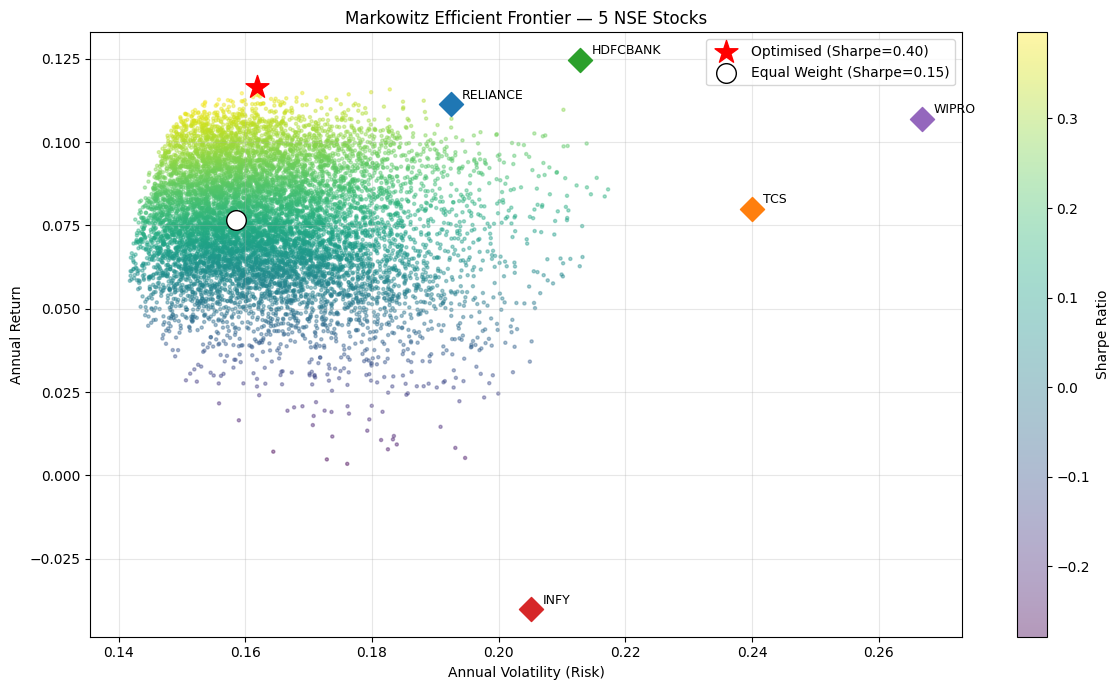

In [ ]:

# Individual stock risk and return
stock_vols    = np.sqrt(np.diag(ann_cov.values))
stock_returns = ann_returns.values

plt.figure(figsize=(12, 7))

scatter = plt.scatter(port_vols, port_returns,
                      c=port_sharpes, cmap='viridis',
                      alpha=0.4, s=5)
plt.colorbar(scatter, label='Sharpe Ratio')

plt.scatter(vol_opt, ret_opt, color='red', s=300,
            marker='*', zorder=5,
            label=f'Optimised (Sharpe={sharpe_opt:.2f})')

plt.scatter(vol_equal, ret_equal, color='white',
            edgecolors='black', s=200, zorder=5,
            label=f'Equal Weight (Sharpe={sharpe_equal:.2f})')

for i, stock in enumerate(stocks):
    plt.scatter(stock_vols[i], stock_returns[i],
                s=150, marker='D', zorder=5)
    plt.annotate(stock.replace('.NS', ''),
                 (stock_vols[i], stock_returns[i]),
                 textcoords='offset points',
                 xytext=(8, 4), fontsize=9)

plt.xlabel('Annual Volatility (Risk)')
plt.ylabel('Annual Return')
plt.title('Markowitz Efficient Frontier — 5 NSE Stocks')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('markowitz_frontier.png', dpi=150, bbox_inches='tight')
plt.show()